#### Goals / TODO of this notebook
- get summary stats of each column and maybe write this to a file
- get histograms for numerical cols, barcharts for categorical cols
- get correl matrix
- take care of missing values with tentative approach: median for numerical cols, mode for categorical cols
- MAYBE: create additional binary column that displays a 0 for intact record and 1 if a missing value had to be replaced
- encode categorical cols - there are different methods of doing this and I am still learning about it. this could affect model performance if not done carefully.
- export out cleaned data for us to begin looking at how to specify model

In [3]:
import pandas as pd
data = pd.read_csv('resampled_loan_data.csv')

In [6]:
import os
import pandas as pd

# Create output directory
output_dir = 'data_head'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# # Option 1: Save as CSV (best for tabular data)
# data.head().to_csv(f"{output_dir}/data_head.csv", index=True)

# Option 2: Save as HTML (nice formatting when opened in browser)
# data.head().to_html(f"{output_dir}/data_head.html")

# Option 3: Save as text with a wide display setting
with open(f"{output_dir}/data_head.txt", 'w') as f:
    # Set pandas display options to show all columns
    with pd.option_context('display.max_columns', None, 
                           'display.width', 1000,
                           'display.max_rows', None):
        f.write(data.head().to_string())

print(f"Data head has been saved to {output_dir} directory in multiple formats")




Data head has been saved to data_head directory in multiple formats


In [8]:
len(data)
data.tail()

count = 0

for col in data:
    count += 1

print(count)




30


In [4]:
# seperate between numerical and categorical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64'])
categorical_cols = data.select_dtypes(include=['object', 'category'])


In [5]:
null_in_col = data.isnull().sum()
missing_percentage = (null_in_col / len(data)) * 100
print(missing_percentage)

loan_amnt                     0.000000
verification_status           0.000000
pub_rec_bankruptcies          0.047619
tax_liens                     0.003333
tot_hi_cred_lim               4.742857
total_bal_ex_mort             3.277619
total_bc_limit                3.277619
total_il_high_credit_limit    4.742857
disbursement_method           0.000000
debt_settlement_flag          0.000000
annual_inc                    0.000000
collections_12_mths_ex_med    0.003810
delinq_2yrs                   0.000000
dti                           0.025714
grade                         0.000000
earliest_cr_line              0.000000
emp_length                    6.532381
home_ownership                0.000000
inq_last_6mths                0.000000
installment                   0.000000
int_rate                      0.000000
last_pymnt_d                  0.441905
out_prncp                     0.000000
out_prncp_inv                 0.000000
pub_rec                       0.000000
purpose                  

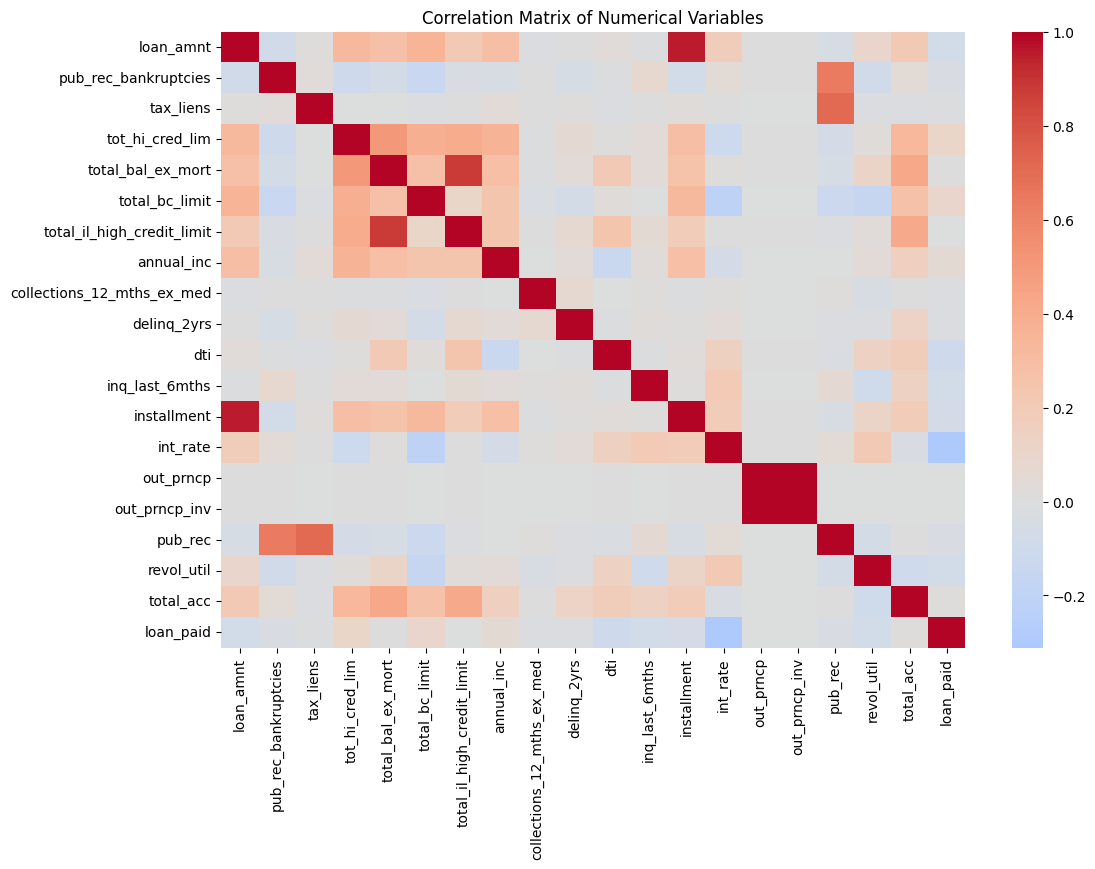

In [6]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


correl_matrix = numerical_cols.corr()

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correl_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


In [9]:

data_imputed = data.copy()

# Create a single indicator column that shows if any value in the row had to be imputed
data_imputed['has_imputed_values'] = data_imputed.isnull().any(axis=1).astype(int)

# For numerical columns: impute with median
for col in numerical_cols:
    # Check if column has missing values
    if data_imputed[col].isnull().sum() > 0:
        # Impute with median
        data_imputed[col] = data_imputed[col].fillna(data_imputed[col].median())

# For categorical columns: impute with mode
for col in categorical_cols:
    # Check if column has missing values
    if data_imputed[col].isnull().sum() > 0:
        # Impute with mode (most frequent value)
        data_imputed[col] = data_imputed[col].fillna(data_imputed[col].mode()[0])

# Verify imputation was successful
print("Remaining missing values after imputation:")
print(data_imputed.isnull().sum().sum())

# Show how many records had imputed values
imputed_count = data_imputed['has_imputed_values'].sum()
total_count = len(data_imputed)
print(f"\nRecords with imputed values: {imputed_count} ({imputed_count/total_count:.2%} of total)")

Remaining missing values after imputation:
0

Records with imputed values: 24220 (11.53% of total)


In [10]:
#simple logistics, tree based (ensemble tree) which is random forest, boosting).
data_imputed.isnull().sum()
data_imputed.head()

,loan_amnt,verification_status,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,...,last_pymnt_d,out_prncp,out_prncp_inv,pub_rec,purpose,revol_util,term,total_acc,loan_paid,has_imputed_values
0,8000,Source Verified,0.0,0.0,148879.0,41401.0,25300.0,33679.0,Cash,N,...,May-2018,0.0,0.0,0.0,credit_card,55.1,36 months,24.0,1,0
1,12750,Verified,0.0,0.0,104074.0,79717.0,0.0,98374.0,Cash,N,...,Mar-2018,0.0,0.0,0.0,debt_consolidation,64.9,36 months,27.0,1,0
2,12000,Source Verified,0.0,0.0,23930.0,16536.0,8800.0,14130.0,Cash,N,...,Nov-2016,0.0,0.0,0.0,debt_consolidation,81.2,36 months,13.0,0,0
3,20000,Verified,0.0,0.0,15800.0,11510.0,8700.0,0.0,Cash,N,...,Nov-2015,0.0,0.0,0.0,debt_consolidation,72.8,60 months,18.0,1,0
4,30000,Not Verified,1.0,0.0,54683.0,26857.0,7500.0,44583.0,Cash,N,...,Jan-2018,0.0,0.0,1.0,debt_consolidation,67.9,60 months,13.0,0,0


In [13]:
import os
import pandas as pd
import numpy as np
from scipy import stats

# Create a directory to store the stats files if it doesn't exist
output_dir = 'column_stats'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# For each numerical column, generate comprehensive stats and save to a file
for col in numerical_cols:
    # Create a clean filename
    filename = f"{output_dir}/{col}_analysis.txt"
    
    # ----- Generate comprehensive statistics -----
    
    # Basic stats
    basic_stats = data[col].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99])
    
    # Calculate additional statistics
    additional_stats = {
        'Missing Values': data[col].isnull().sum(),
        'Missing Percentage': data[col].isnull().mean() * 100,
        'Unique Values': data[col].nunique(),
        'Skewness': data[col].skew(),
        'Kurtosis': data[col].kurtosis(),
        'IQR': data[col].quantile(0.75) - data[col].quantile(0.25),
        'Mode': data[col].mode().iloc[0] if not data[col].mode().empty else None
    }
    
    # Relationship with target variable (loan_paid)
    if 'loan_paid' in data.columns:
        target_stats = {
            'Mean for paid loans': data[data['loan_paid']==1][col].mean(),
            'Mean for unpaid loans': data[data['loan_paid']==0][col].mean(),
            'Median for paid loans': data[data['loan_paid']==1][col].median(),
            'Median for unpaid loans': data[data['loan_paid']==0][col].median(),
            'Point-Biserial Correlation': stats.pointbiserialr(data['loan_paid'], data[col].fillna(data[col].median()))[0]
        }
    
    # Outlier analysis
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_stats = {
        'Lower outlier bound': lower_bound,
        'Upper outlier bound': upper_bound,
        'Outliers count': len(data[(data[col] < lower_bound) | (data[col] > upper_bound)]),
        'Outliers percentage': len(data[(data[col] < lower_bound) | (data[col] > upper_bound)]) / len(data) * 100
    }
    
    # Correlation with other important variables
    key_vars = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'total_acc', 'revol_util', 'loan_paid']
    key_vars = [var for var in key_vars if var in data.columns and var != col]
    
    correlation_stats = {}
    for var in key_vars:
        if pd.api.types.is_numeric_dtype(data[var]):
            correlation = data[[col, var]].corr().iloc[0, 1]
            correlation_stats[f'Correlation with {var}'] = correlation
    
    # ----- Write all information to the text file -----
    with open(filename, 'w') as f:
        f.write(f"COMPREHENSIVE ANALYSIS FOR: {col}\n")
        f.write("="*60 + "\n\n")
        
        f.write("1. BASIC STATISTICS\n")
        f.write("-"*60 + "\n")
        f.write(basic_stats.to_string() + "\n\n")
        
        f.write("2. ADDITIONAL STATISTICS\n")
        f.write("-"*60 + "\n")
        for key, value in additional_stats.items():
            f.write(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}\n")
        f.write("\n\n")
        
        if 'loan_paid' in data.columns:
            f.write("3. RELATIONSHIP WITH LOAN STATUS\n")
            f.write("-"*60 + "\n")
            for key, value in target_stats.items():
                f.write(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}\n")
            f.write("\n\n")
        
        f.write("4. OUTLIER ANALYSIS\n")
        f.write("-"*60 + "\n")
        for key, value in outlier_stats.items():
            f.write(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}\n")
        f.write("\n\n")
        
        if correlation_stats:
            f.write("5. CORRELATIONS WITH KEY VARIABLES\n")
            f.write("-"*60 + "\n")
            for key, value in sorted(correlation_stats.items(), key=lambda x: abs(x[1]), reverse=True):
                f.write(f"{key}: {value:.4f}\n")
            f.write("\n\n")
        
        # Special insights for key financial variables
        if col in ['loan_amnt', 'int_rate', 'installment', 'annual_inc']:
            f.write("6. FINANCIAL INSIGHTS\n")
            f.write("-"*60 + "\n")
            
            if col == 'loan_amnt':
                f.write(f"Average Loan Amount: ${data[col].mean():.2f}\n")
                f.write(f"Typical Loan Range: ${data[col].quantile(0.25):.2f} to ${data[col].quantile(0.75):.2f}\n")
                if 'term' in data.columns:
                    for term in data['term'].unique():
                        f.write(f"Average Loan for {term}: ${data[data['term']==term][col].mean():.2f}\n")
            
            if col == 'int_rate':
                f.write(f"Average Interest Rate: {data[col].mean():.2f}%\n")
                f.write(f"Rate Range: {data[col].quantile(0.1):.2f}% to {data[col].quantile(0.9):.2f}%\n")
                if 'term' in data.columns:
                    for term in data['term'].unique():
                        f.write(f"Average Rate for {term}: {data[data['term']==term][col].mean():.2f}%\n")
    
    print(f"Created comprehensive analysis for {col}")

print(f"\nAll analysis files have been generated in the '{output_dir}' directory.")

Created comprehensive analysis for loan_amnt
Created comprehensive analysis for pub_rec_bankruptcies
Created comprehensive analysis for tax_liens
Created comprehensive analysis for tot_hi_cred_lim
Created comprehensive analysis for total_bal_ex_mort
Created comprehensive analysis for total_bc_limit
Created comprehensive analysis for total_il_high_credit_limit
Created comprehensive analysis for annual_inc
Created comprehensive analysis for collections_12_mths_ex_med
Created comprehensive analysis for delinq_2yrs
Created comprehensive analysis for dti
Created comprehensive analysis for inq_last_6mths
Created comprehensive analysis for installment
Created comprehensive analysis for int_rate
Created comprehensive analysis for out_prncp
Created comprehensive analysis for out_prncp_inv
Created comprehensive analysis for pub_rec
Created comprehensive analysis for revol_util
Created comprehensive analysis for total_acc
Created comprehensive analysis for loan_paid

All analysis files have been 

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create a directory for histograms
viz_dir = 'column_histograms'
if not os.path.exists(viz_dir):
    os.makedirs(viz_dir)

# Set a better visual style
plt.style.use('seaborn-v0_8-whitegrid')

# Function to create better histograms
def create_histogram(data, column, output_dir):
    # Skip if all values are missing
    if data[column].isnull().all():
        print(f"Skipping {column} - all values are null")
        return
    
    # Create figure with enough height for two plots (regular and log-transformed)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
    
    # Get column stats for better binning
    non_null_data = data[column].dropna()
    
    # Calculate better bin count using Freedman-Diaconis rule
    # This helps prevent the "single spike" problem
    iqr = np.percentile(non_null_data, 75) - np.percentile(non_null_data, 25)
    bin_width = 2 * iqr / (len(non_null_data) ** (1/3))
    bin_count = int(np.ceil((non_null_data.max() - non_null_data.min()) / bin_width)) if bin_width > 0 else 30
    bin_count = min(100, max(10, bin_count))  # Reasonable limits on bin count
    
    # ----- Regular histogram -----
    ax1.set_title(f"Distribution of {column}", fontsize=14, pad=10)
    
    # Calculate skewness to provide context
    skewness = non_null_data.skew()
    
    # Plot histogram with KDE
    sns.histplot(non_null_data, bins=bin_count, kde=True, ax=ax1, 
                 color='steelblue', edgecolor='black', alpha=0.7)
    
    # Add mean and median lines
    ax1.axvline(non_null_data.mean(), color='red', linestyle='--', 
                linewidth=1.5, label=f'Mean: {non_null_data.mean():.2f}')
    ax1.axvline(non_null_data.median(), color='green', linestyle='-', 
                linewidth=1.5, label=f'Median: {non_null_data.median():.2f}')
    
    # Add skewness information
    skew_text = f"Skewness: {skewness:.2f}"
    if abs(skewness) < 0.5:
        skew_text += " (approximately symmetric)"
    elif skewness > 0:
        skew_text += " (right-skewed)"
    else:
        skew_text += " (left-skewed)"
    
    ax1.text(0.05, 0.95, skew_text, transform=ax1.transAxes, 
             bbox=dict(facecolor='white', alpha=0.7), verticalalignment='top')
    
    ax1.legend()
    ax1.set_xlabel(column, fontsize=12)
    ax1.set_ylabel("Frequency", fontsize=12)
    
    # Add grid for readability
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # ----- Log-transformed histogram (if appropriate) -----
    # Only do log transform if data is positive and skewed
    if non_null_data.min() > 0 and abs(skewness) > 1:
        log_data = np.log1p(non_null_data)  # log(1+x) to handle small values
        
        # Recalculate bins for log-transformed data
        log_iqr = np.percentile(log_data, 75) - np.percentile(log_data, 25)
        log_bin_width = 2 * log_iqr / (len(log_data) ** (1/3))
        log_bin_count = int(np.ceil((log_data.max() - log_data.min()) / log_bin_width)) if log_bin_width > 0 else 30
        log_bin_count = min(100, max(10, log_bin_count))
        
        ax2.set_title(f"Log-Transformed Distribution of {column}", fontsize=14, pad=10)
        
        # Plot log-transformed histogram with KDE
        sns.histplot(log_data, bins=log_bin_count, kde=True, ax=ax2, 
                     color='darkgreen', edgecolor='black', alpha=0.7)
        
        # Add mean and median lines for log data
        ax2.axvline(log_data.mean(), color='red', linestyle='--', 
                    linewidth=1.5, label=f'Log Mean: {log_data.mean():.2f}')
        ax2.axvline(log_data.median(), color='green', linestyle='-', 
                    linewidth=1.5, label=f'Log Median: {log_data.median():.2f}')
        
        # Add skewness information for log data
        log_skew = log_data.skew()
        log_skew_text = f"Log Skewness: {log_skew:.2f}"
        if abs(log_skew) < 0.5:
            log_skew_text += " (approximately symmetric)"
        elif log_skew > 0:
            log_skew_text += " (right-skewed)"
        else:
            log_skew_text += " (left-skewed)"
        
        ax2.text(0.05, 0.95, log_skew_text, transform=ax2.transAxes, 
                 bbox=dict(facecolor='white', alpha=0.7), verticalalignment='top')
        
        ax2.legend()
        ax2.set_xlabel(f"log(1 + {column})", fontsize=12)
        ax2.set_ylabel("Frequency", fontsize=12)
        ax2.grid(True, linestyle='--', alpha=0.7)
    else:
        # If we can't log transform, show different visualization - like boxplot
        ax2.set_title(f"Boxplot of {column}", fontsize=14, pad=10)
        sns.boxplot(x=non_null_data, ax=ax2, color='lightblue')
        
        # Add outlier information
        q1, q3 = np.percentile(non_null_data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = non_null_data[(non_null_data < lower_bound) | (non_null_data > upper_bound)]
        
        if len(outliers) > 0:
            outlier_text = f"Outliers: {len(outliers)} ({len(outliers)/len(non_null_data):.2%} of data)"
            ax2.text(0.05, 0.95, outlier_text, transform=ax2.transAxes, 
                     bbox=dict(facecolor='white', alpha=0.7), verticalalignment='top')
        
        ax2.set_xlabel(column, fontsize=12)
        ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Add information about missing values
    missing_count = data[column].isnull().sum()
    missing_percent = missing_count / len(data) * 100
    
    if missing_count > 0:
        fig.text(0.5, 0.01, f"Missing values: {missing_count} ({missing_percent:.2f}%)", 
                 ha='center', fontsize=12, bbox=dict(facecolor='lightyellow', alpha=0.7))
    
    plt.tight_layout(pad=3)
    
    # Save the figure
    plt.savefig(f"{output_dir}/{column}_histogram.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Created histogram for {column}")

# Generate histograms for all numerical columns
for col in numerical_cols:
    create_histogram(data, col, viz_dir)

print(f"\nAll histograms have been generated in the '{viz_dir}' directory.")

Created histogram for loan_amnt
Created histogram for pub_rec_bankruptcies
Created histogram for tax_liens
Created histogram for tot_hi_cred_lim
Created histogram for total_bal_ex_mort
Created histogram for total_bc_limit
Created histogram for total_il_high_credit_limit
Created histogram for annual_inc
Created histogram for collections_12_mths_ex_med
Created histogram for delinq_2yrs
Created histogram for dti
Created histogram for inq_last_6mths
Created histogram for installment
Created histogram for int_rate
Created histogram for out_prncp
Created histogram for out_prncp_inv
Created histogram for pub_rec
Created histogram for revol_util
Created histogram for total_acc
Created histogram for loan_paid

All histograms have been generated in the 'column_histograms' directory.


In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a directory for bar charts
bar_chart_dir = 'categorical_barcharts'
if not os.path.exists(bar_chart_dir):
    os.makedirs(bar_chart_dir)

# Load the data
data = pd.read_csv('resampled_loan_data.csv')

# Separate between numerical and categorical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64'])
categorical_cols = data.select_dtypes(include=['object', 'category'])

# Function to create better bar charts for categorical variables
def create_bar_chart(data, column, output_dir, is_near_categorical=False):
    plt.figure(figsize=(12, 7))
    
    # Handle missing values
    missing_count = data[column].isnull().sum()
    valid_data = data[column].dropna()
    
    # Calculate value counts and percentages
    value_counts = valid_data.value_counts().sort_values(ascending=False)
    value_percentages = (value_counts / len(valid_data) * 100).round(1)
    
    # Prepare the plot data
    if len(value_counts) > 15:
        # If there are too many categories, limit to top N
        plot_data = value_counts.nlargest(15)
        plot_percentages = value_percentages.nlargest(15)
        title = f"Top 15 Categories in {column}"
    else:
        plot_data = value_counts
        plot_percentages = value_percentages
        title = f"Categories in {column}"
    
    # Add info on whether this is a "near categorical" variable
    if is_near_categorical:
        title += " (Near-Categorical Numerical Variable)"
    
    # Create the bar chart
    ax = sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')
    
    # Add count and percentage labels on the bars
    for i, (count, percentage) in enumerate(zip(plot_data, plot_percentages)):
        ax.text(i, count/2, f"{count}\n({percentage}%)", 
                ha='center', va='center', color='white', fontweight='bold')
    
    # Formatting
    plt.title(title, fontsize=14, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(column, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    
    # Add information about missing values if any
    if missing_count > 0:
        plt.figtext(0.5, 0.01, f"Missing values: {missing_count} ({missing_count/len(data)*100:.1f}%)", 
                    ha='center', fontsize=10, bbox=dict(facecolor='lightyellow', alpha=0.5))
    
    plt.tight_layout(pad=3)
    plt.savefig(f"{output_dir}/{column}_barchart.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Created bar chart for {column}")

# Function to determine if a numerical variable is "near categorical"
def is_near_categorical(series):
    # Drop NaN values
    valid_data = series.dropna()
    
    # Check the number of unique values
    unique_values = valid_data.nunique()
    
    # First criterion: few unique values
    if unique_values < 10:
        return True
        
    # Second criterion: if a small set of values accounts for most of the data
    value_counts = valid_data.value_counts()
    top_5_percent = value_counts.nlargest(5).sum() / len(valid_data) * 100
    
    if top_5_percent > 85:  # If top 5 values account for >85% of data
        return True
    
    # Third criterion: check if most values are integers (suggesting categories)
    if series.dtype in ['float64', 'float32']:
        # Check if most float values are actually integers
        is_integer = np.isclose(valid_data, np.round(valid_data), rtol=1e-8)
        if is_integer.mean() > 0.95 and unique_values < 20:  # 95% are integers with <20 unique values
            return True
    
    return False

# Create bar charts for categorical variables
print("Creating bar charts for categorical variables...")
for col in categorical_cols:
    create_bar_chart(data, col, bar_chart_dir)

# Identify "near categorical" numerical variables
near_categorical = []
for col in numerical_cols:
    if is_near_categorical(data[col]):
        near_categorical.append(col)

print("\nIdentified 'near-categorical' numerical variables:")
for col in near_categorical:
    print(f"- {col} (with {data[col].nunique()} unique values)")

# Create bar charts for near-categorical variables
print("\nCreating bar charts for near-categorical variables...")
for col in near_categorical:
    create_bar_chart(data, col, bar_chart_dir, is_near_categorical=True)

print(f"\nAll bar charts have been saved to the '{bar_chart_dir}' directory.")

Creating bar charts for categorical variables...


C:\Users\chris\AppData\Local\Temp\ipykernel_856\3037050642.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')


Created bar chart for verification_status


C:\Users\chris\AppData\Local\Temp\ipykernel_856\3037050642.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')


Created bar chart for disbursement_method


...

Created bar chart for out_prncp_inv


C:\Users\chris\AppData\Local\Temp\ipykernel_856\3037050642.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')


Created bar chart for pub_rec


C:\Users\chris\AppData\Local\Temp\ipykernel_856\3037050642.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis')


Created bar chart for loan_paid

All bar charts have been saved to the 'categorical_barcharts' directory.


In [22]:
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Create a directory for histograms
# hist_dir = 'numerical_histograms'
# if not os.path.exists(hist_dir):
#     os.makedirs(hist_dir)

# # Load the data
# data = pd.read_csv('resampled_loan_data.csv')

# # Identify numerical columns
# numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# # These variables might be better as bar charts since they are "near-categorical"
# likely_categorical = ['loan_paid', 'pub_rec', 'pub_rec_bankruptcies', 'tax_liens', 
#                       'collections_12_mths_ex_med', 'delinq_2yrs', 'inq_last_6mths']

# # Create histograms for truly continuous variables
# true_numerical = [col for col in numerical_cols if col not in likely_categorical]

# print(f"Creating histograms for {len(true_numerical)} numerical variables...")

# for col in true_numerical:
#     plt.figure(figsize=(10, 6))
    
#     # Create the histogram
#     sns.histplot(data[col].dropna(), kde=False, bins=30)
    
#     # Add title and labels
#     plt.title(f"Distribution of {col}", fontsize=14)
#     plt.xlabel(col, fontsize=12)
#     plt.ylabel("Frequency", fontsize=12)
    
#     # Add information about missing values if any
#     missing_count = data[col].isnull().sum()
#     if missing_count > 0:
#         missing_percent = missing_count / len(data) * 100
#         plt.figtext(0.5, 0.01, f"Missing values: {missing_count} ({missing_percent:.2f}%)", 
#                     ha='center', fontsize=10, bbox=dict(facecolor='lightyellow', alpha=0.5))
    
#     # Save the histogram
#     plt.tight_layout()
#     plt.savefig(f"{hist_dir}/{col}_histogram.png", dpi=300, bbox_inches='tight')
#     plt.close()
    
#     print(f"Created histogram for {col}")

# print(f"\nAll histograms have been saved to the '{hist_dir}' directory.")

Creating histograms for 13 numerical variables...
Created histogram for loan_amnt
Created histogram for tot_hi_cred_lim
Created histogram for total_bal_ex_mort
Created histogram for total_bc_limit
Created histogram for total_il_high_credit_limit
Created histogram for annual_inc
Created histogram for dti
Created histogram for installment
Created histogram for int_rate
Created histogram for out_prncp
Created histogram for out_prncp_inv
Created histogram for revol_util
Created histogram for total_acc

All histograms have been saved to the 'numerical_histograms' directory.


In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create a directory for histograms
hist_dir = 'improved_histograms'
if not os.path.exists(hist_dir):
    os.makedirs(hist_dir)

# Load the data
data = pd.read_csv('resampled_loan_data.csv')

# Identify numerical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# These variables might be better as bar charts since they are "near-categorical"
likely_categorical = ['loan_paid', 'pub_rec', 'pub_rec_bankruptcies', 'tax_liens', 
                     'collections_12_mths_ex_med', 'delinq_2yrs', 'inq_last_6mths']

# Create histograms for truly continuous variables
true_numerical = [col for col in numerical_cols if col not in likely_categorical]

print(f"Creating improved histograms for {len(true_numerical)} numerical variables...")

for col in true_numerical:
    # Skip if column is all nulls
    if data[col].isnull().all():
        print(f"Skipping {col} - all values are null")
        continue
    
    # Get non-null data for analysis
    valid_data = data[col].dropna()
    
    # Basic statistics for annotations
    mean_val = valid_data.mean()
    median_val = valid_data.median()
    skewness = valid_data.skew()
    n_zeros = (valid_data == 0).sum()
    pct_zeros = n_zeros / len(valid_data) * 100
    
    # Detect if distribution is highly concentrated at one value
    max_freq_val = valid_data.value_counts().idxmax()
    max_freq_count = valid_data.value_counts().max()
    max_freq_pct = max_freq_count / len(valid_data) * 100
    is_concentrated = max_freq_pct > 80  # If >80% of values are the same
    
    # Determine if log transformation would be helpful (positive skew and positive values)
    needs_log_transform = skewness > 3 and valid_data.min() >= 0
    
    # Determine appropriate binning
    if is_concentrated:
        # For concentrated data, we'll do a zoomed-in view as well
        bins = 30
    else:
        # For non-concentrated data, use Freedman-Diaconis rule for bin width
        q75, q25 = np.percentile(valid_data, [75, 25])
        iqr = q75 - q25
        bin_width = 2 * iqr / (len(valid_data) ** (1/3)) if iqr > 0 else 30
        bins = max(30, min(100, int(np.ceil((valid_data.max() - valid_data.min()) / bin_width))))
    
    # Create a figure with potentially two subplots (regular and transformed)
    if needs_log_transform or is_concentrated:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
    else:
        fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # First plot: Standard histogram (possibly with some adjustments)
    if is_concentrated and max_freq_val == 0:
        # For variables concentrated at zero, show basic histogram
        sns.histplot(valid_data, bins=bins, kde=False, ax=ax1)
        ax1.set_title(f"Distribution of {col} (Concentrated at zero: {pct_zeros:.1f}%)", fontsize=14)
        
        # Annotate the zero spike
        ax1.annotate(f"{n_zeros} zeros ({pct_zeros:.1f}%)", 
                    xy=(0, 0), xytext=(10, max_freq_count/2),
                    arrowprops=dict(facecolor='red', shrink=0.05))
    else:
        # For non-zero-concentrated data, show regular histogram
        sns.histplot(valid_data, bins=bins, kde=True, ax=ax1)
        ax1.set_title(f"Distribution of {col}", fontsize=14)
    
    # Add mean and median lines
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')
    
    # Add skewness info
    skew_text = f"Skewness: {skewness:.2f}"
    if abs(skewness) < 0.5:
        skew_text += " (approximately symmetric)"
    elif skewness > 0:
        skew_text += " (right-skewed)"
    else:
        skew_text += " (left-skewed)"
    
    ax1.text(0.05, 0.95, skew_text, transform=ax1.transAxes, 
             bbox=dict(facecolor='white', alpha=0.7), verticalalignment='top')
    
    ax1.legend()
    ax1.set_xlabel(col, fontsize=12)
    ax1.set_ylabel("Frequency", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Second plot: Either log-transformed or zoomed view
    if needs_log_transform:
        # Log transformation for highly skewed data
        log_data = np.log1p(valid_data)  # log(1+x) to handle zeros
        
        sns.histplot(log_data, bins=bins, kde=True, ax=ax2, color='darkgreen')
        ax2.set_title(f"Log-Transformed Distribution of {col}", fontsize=14)
        
        # Add mean and median lines for log data
        log_mean = log_data.mean()
        log_median = log_data.median()
        ax2.axvline(log_mean, color='red', linestyle='--', linewidth=1.5, label=f'Log Mean: {log_mean:.2f}')
        ax2.axvline(log_median, color='green', linestyle='-', linewidth=1.5, label=f'Log Median: {log_median:.2f}')
        
        ax2.legend()
        ax2.set_xlabel(f"log(1 + {col})", fontsize=12)
        ax2.set_ylabel("Frequency", fontsize=12)
        ax2.grid(True, linestyle='--', alpha=0.7)
        
    elif is_concentrated:
        # For concentrated data, create a zoomed-in view excluding the dominant value
        filtered_data = valid_data[valid_data != max_freq_val]
        
        if len(filtered_data) > 0:
            sns.histplot(filtered_data, bins=bins, kde=True, ax=ax2, color='darkgreen')
            ax2.set_title(f"Zoomed View of {col} (excluding {max_freq_val})", fontsize=14)
            
            # Add mean and median lines for the filtered data
            if len(filtered_data) > 1:  # Need at least 2 points for statistics
                filtered_mean = filtered_data.mean()
                filtered_median = filtered_data.median()
                ax2.axvline(filtered_mean, color='red', linestyle='--', linewidth=1.5, 
                            label=f'Mean (excl. {max_freq_val}): {filtered_mean:.2f}')
                ax2.axvline(filtered_median, color='green', linestyle='-', linewidth=1.5, 
                            label=f'Median (excl. {max_freq_val}): {filtered_median:.2f}')
                ax2.legend()
            
            ax2.set_xlabel(col, fontsize=12)
            ax2.set_ylabel("Frequency", fontsize=12)
            ax2.grid(True, linestyle='--', alpha=0.7)
        else:
            # If there's no data after filtering, show a message
            ax2.text(0.5, 0.5, "No data available after removing the dominant value", 
                     ha='center', va='center', fontsize=14)
            ax2.set_title(f"Zoomed View of {col} (excluding {max_freq_val})", fontsize=14)
    
    # Add information about missing values if any
    missing_count = data[col].isnull().sum()
    if missing_count > 0:
        missing_percent = missing_count / len(data) * 100
        plt.figtext(0.5, 0.01, f"Missing values: {missing_count} ({missing_percent:.2f}%)", 
                    ha='center', fontsize=10, bbox=dict(facecolor='lightyellow', alpha=0.5))
    
    plt.tight_layout(pad=2)
    plt.savefig(f"{hist_dir}/{col}_histogram.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Created improved histogram for {col}")

print(f"\nAll improved histograms have been saved to the '{hist_dir}' directory.")

Creating improved histograms for 13 numerical variables...
Created improved histogram for loan_amnt
Created improved histogram for tot_hi_cred_lim
Created improved histogram for total_bal_ex_mort
Created improved histogram for total_bc_limit
Created improved histogram for total_il_high_credit_limit
Created improved histogram for annual_inc
Created improved histogram for dti
Created improved histogram for installment
Created improved histogram for int_rate
Created improved histogram for out_prncp
Created improved histogram for out_prncp_inv
Created improved histogram for revol_util
Created improved histogram for total_acc

All improved histograms have been saved to the 'improved_histograms' directory.
